<a href="https://colab.research.google.com/github/jayshivankar/AdaBoost-Classifier/blob/main/Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data Source - https://drive.google.com/drive/folders/10SUoVOHnv95fLr-w2HSktjQUd96jXA3U?usp=sharing
# Data File - https://drive.google.com/file/d/1b3ZtbqWw0knl7yJKHrHYuflLpJewHfM6/view?usp=drive_link

In [ ]:
# Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Avoid harmless warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Reading the data
data = pd.read_csv('/content/drive/MyDrive/Datasets/Input/bank.csv')
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
# Mapping for month
maps = {'jan': 1, 'feb': 2, 'mar' : 3, 'apr': 4, 'may': 5, 'jun': 6,
        'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}

# Apply the mapping
data['month'] = data['month'].map(maps)

In [ ]:
# label encoding the data
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for cols in data:
    if data[cols].dtype == 'O':
        data[cols] = encoder.fit_transform(data[cols])

In [ ]:
# data sample
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,5,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,5,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,5,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,5,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,5,673,2,-1,0,3,1


In [ ]:
# data dimension
data.shape

(11162, 17)

In [ ]:
# dependency split
x = data.drop('deposit', axis=1)
y = data['deposit']

# train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)


Training Accuracy: 100.0 %
Testing Accuracy: 79.0


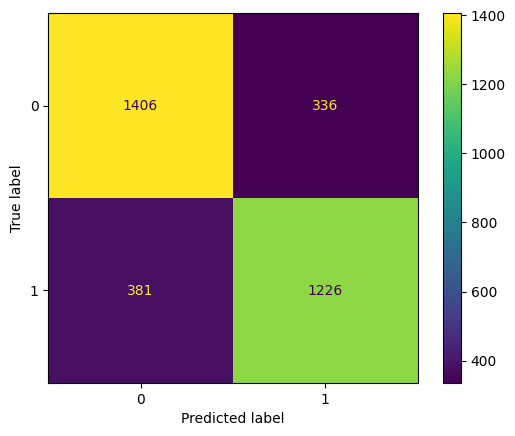

In [ ]:
# Decision tree model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(x_train, y_train)
print('Training Accuracy:', round(model.score(x_train, y_train)*100, 2), '%')

# model prediction
y_pred = model.predict(x_test)

# model metrics
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print('Testing Accuracy:', round(accuracy_score(y_test, y_pred),2)*100)

Training Accuracy: 83.26 %
Testing Accuracy: 83.0


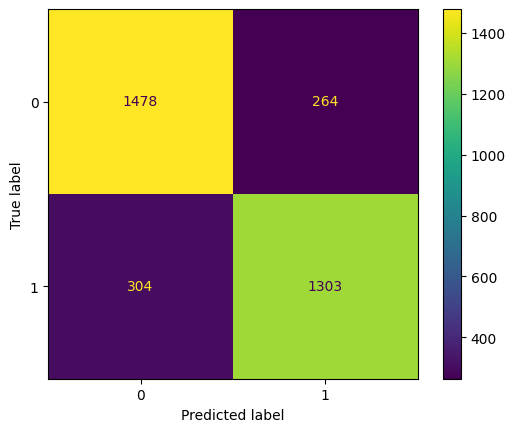

In [ ]:
# default estimator

# Adaboost Classifier
from sklearn.ensemble import AdaBoostClassifier

# ada boost model
adaboost_model_def = AdaBoostClassifier(n_estimators=1000)
adaboost_model_def.fit(x_train, y_train)
print('Training Accuracy:', round(adaboost_model_def.score(x_train, y_train)*100, 2), '%')

# model prediction
y_pred_ada_def = adaboost_model_def.predict(x_test)

# model metrics
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ada_def)
print('Testing Accuracy:', round(accuracy_score(y_test, y_pred_ada_def),2)*100)

Training Accuracy: 84.54 %
Testing Accuracy: 84.0


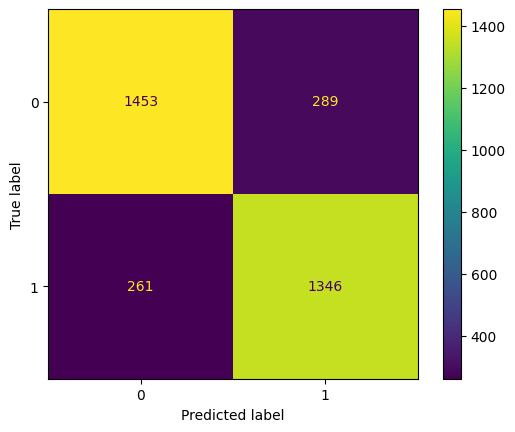

In [ ]:
# Adaboost Classifier
from sklearn.ensemble import AdaBoostClassifier

# estimator
tree_clf = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=2)

# ada boost model
adaboost_model = AdaBoostClassifier(estimator=tree_clf, n_estimators=100)
adaboost_model.fit(x_train, y_train)
print('Training Accuracy:', round(adaboost_model.score(x_train, y_train)*100, 2), '%')

# model prediction
y_pred_ada = adaboost_model.predict(x_test)

# model metrics
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ada)
print('Testing Accuracy:', round(accuracy_score(y_test, y_pred_ada),2)*100)